# Anisotropic Materials & Birefringence in FDTDX

This notebook shows how to represent **anisotropic materials** in
[FDTDX](https://fdtdx.readthedocs.io/en/latest/) and uses that capability to simulate
**birefringence** — the phenomenon in which a material has a different refractive index
depending on the polarization (and propagation direction) of light passing through it.

## 1. Setup

In [57]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from IPython.display import Video

import fdtdx

%matplotlib inline


## 2. Representing anisotropic materials in FDTDX

Using [`fdtdx.Material`](https://fdtdx.readthedocs.io/en/latest/api/fdtdx.Material.html) docs,
every material property (`permittivity`, `permeability`, `electric_conductivity`,
`magnetic_conductivity`) is stored internally as a full 3x3 tensor
(a 9-tuple `(xx, xy, xz, yx, yy, yz, zx, zy, zz)`). We can supply it at three levels of
generality:

| Input you provide | Meaning | Example |
|---|---|---|
| scalar `float` | **isotropic** — same value on all 3 diagonal entries, no off-diagonal terms | `permittivity=2.25` |
| 3-tuple `(εx, εy, εz)` | **diagonally anisotropic** (e.g. a uniaxial or biaxial crystal aligned with the grid axes) | `permittivity=(2.75, 2.75, 2.21)` |
| 9-tuple or nested 3x3 | **fully anisotropic**, including off-diagonal terms (e.g. a crystal whose optic axis is *tilted* relative to the simulation grid, or a gyrotropic medium) | `permittivity=((2.48, 0, 0.27), (0, 2.75, 0), (0.27, 0, 2.48))` |

`Material` also exposes convenience flags such as `is_isotropic_permittivity`,
`is_diagonally_anisotropic_permittivity` and `is_all_diagonally_anisotropic` that we can use
to sanity-check what we built.


In [60]:
# (a) Isotropic material -- e.g. plain glass
glass = fdtdx.Material(permittivity=2.25)  # n = 1.5
print("Isotropic glass:")
print("  permittivity tensor:", glass.permittivity)
print("  is_isotropic_permittivity:", glass.is_isotropic_permittivity)

# (b) Diagonally anisotropic material -- a uniaxial crystal with its optic axis
# aligned with the z grid axis: eps_x = eps_y = eps_o (ordinary), eps_z = eps_e (extraordinary)
uniaxial = fdtdx.Material(permittivity=(2.749, 2.749, 2.208))
print("\nUniaxial crystal (optic axis along grid z):")
print("  permittivity tensor:", uniaxial.permittivity)
print("  is_diagonally_anisotropic_permittivity:", uniaxial.is_diagonally_anisotropic_permittivity)
print("  is_isotropic_permittivity:", uniaxial.is_isotropic_permittivity)

# (c) Fully anisotropic material -- same uniaxial crystal, but with its optic axis
# tilted by 30 degrees in the x-z plane relative to the simulation grid.
# This introduces off-diagonal (xz / zx) tensor components.
def tilted_uniaxial_permittivity(eps_o, eps_e, theta_rad):
    """Permittivity tensor of a uniaxial crystal whose optic axis is rotated by
    `theta_rad` about the y-axis (i.e. tilted within the x-z plane)."""
    c, s = np.cos(theta_rad), np.sin(theta_rad)
    exx = eps_o * c**2 + eps_e * s**2
    ezz = eps_o * s**2 + eps_e * c**2
    exz = (eps_e - eps_o) * s * c
    return (
        (exx, 0.0, exz),
        (0.0, eps_o, 0.0),
        (exz, 0.0, ezz),
    )

tilted = fdtdx.Material(permittivity=tilted_uniaxial_permittivity(2.749, 2.208, np.deg2rad(30)))
print("\nTilted uniaxial crystal (optic axis at 30 deg to grid z):")
print("  permittivity tensor:", tilted.permittivity)
print("  is_all_diagonally_anisotropic:", tilted.is_all_diagonally_anisotropic)
print("  is_isotropic_permittivity:", tilted.is_isotropic_permittivity)

Isotropic glass:
  permittivity tensor: (2.25, 0.0, 0.0, 0.0, 2.25, 0.0, 0.0, 0.0, 2.25)
  is_isotropic_permittivity: True

Uniaxial crystal (optic axis along grid z):
  permittivity tensor: (2.749, 0.0, 0.0, 0.0, 2.749, 0.0, 0.0, 0.0, 2.208)
  is_diagonally_anisotropic_permittivity: True
  is_isotropic_permittivity: False

Tilted uniaxial crystal (optic axis at 30 deg to grid z):
  permittivity tensor: (np.float64(2.6137500000000005), 0.0, np.float64(-0.2342598717236906), 0.0, 2.749, 0.0, np.float64(-0.2342598717236906), 0.0, np.float64(2.3432500000000003))
  is_all_diagonally_anisotropic: False
  is_isotropic_permittivity: False


## 3. The physics of birefringence

A **birefringent** material (typically a crystal with a non-cubic lattice, e.g. calcite or
quartz) has an optical response that depends on the direction of the electric field relative
to a special crystal direction called the **optic axis**.

For the simplest case — a *uniaxial* crystal — there are two principal refractive indices:

* **ordinary index** ($n_o$): seen by light polarized *perpendicular* to the optic axis
* **extraordinary index** ($n_e$): seen by light polarized *parallel* to the optic axis

Because ($n_o \neq n_e$), the two polarization components of a light wave travel at different
phase velocities inside the crystal. Two classic consequences follow:

1. **Phase retardation (waveplates):** if the wave travels *perpendicular* to the optic axis,
   both polarization components travel in the same direction but accumulate a *phase
   difference* proportional to ($(n_o - n_e) \cdot d / \lambda$), where ($d$) is the
   thickness. This is exactly how quarter- and half-waveplates work, and is what we simulate
   below.
2. **Spatial walk-off (double refraction):** if the optic axis is *tilted* relative to the
   propagation direction, the ordinary and extraordinary rays refract at (slightly) different
   angles and physically separate inside the crystal — the effect calcite is famous for.

We'll simulate case : a slab of a calcite-like uniaxial crystal acting as a waveplate.
We use representative, non-dispersive values ($n_o \approx 1.658$), ($n_e \approx 1.486$)
(close to calcite's values near the visible/NIR) purely for illustration — FDTDX's `Material`
here is non-dispersive, so we are not modeling calcite's exact wavelength-dependent indices.


In [63]:
# Representative (non-dispersive) calcite-like indices
n_o = 1.658   # ordinary index
n_e = 1.486   # extraordinary index (n_e < n_o -> "negative" uniaxial crystal, like calcite)
eps_o = n_o**2
eps_e = n_e**2
delta_n = n_o - n_e

wavelength = 1.55e-6  # source wavelength (m)

# Thickness for a quarter-wave plate: (n_o - n_e) * d = lambda / 4
slab_thickness = wavelength / (4 * delta_n)
print(f"eps_o = {eps_o:.4f}, eps_e = {eps_e:.4f}, delta_n = {delta_n:.4f}")
print(f"Quarter-wave slab thickness: {slab_thickness*1e6:.3f} um")

eps_o = 2.7490, eps_e = 2.2082, delta_n = 0.1720
Quarter-wave slab thickness: 2.253 um


## 4. Building a birefringent-slab (waveplate) simulation

* A `SimulationVolume` filled with vacuum.
* PML boundaries on all six sides (`BoundaryConfig.from_uniform_bound`).
* A `GaussianPlaneSource` polarized at **45 deg** (equal `Ex` and `Ey` amplitude) so that both
  the ordinary and extraordinary components are excited equally.
* A birefringent slab (`UniformMaterialObject`) with its **optic axis along x**, so `Ex` sees
  ($\varepsilon_e$) and `Ey`/`Ez` see ($\varepsilon_o$) — this is the diagonally anisotropic
  `Material` from Section 2(b), just permuted onto the x-axis.
* Point `FieldDetector`s just before and just after the slab, recording `Ex`/`Ey` over time so
  we can see the phase retardation appear.
* An `EnergyDetector` for a video of the field propagating through the slab.


In [66]:
key = jax.random.PRNGKey(42)
object_list = []
constraints = []

config = fdtdx.SimulationConfig(
    time=150e-15,        # 150 fs -- enough for the pulse to cross the domain a few times over
    grid=fdtdx.UniformGrid(spacing=50e-9),    # 50 nm grid spacing
    dtype=jnp.float32,
    courant_factor=0.99,
)

vol_x, vol_y, vol_z = 3e-6, 3e-6, 8e-6

volume = fdtdx.SimulationVolume(
    partial_real_shape=(vol_x, vol_y, vol_z),
    material=fdtdx.Material(permittivity=1.0, permeability=1.0),  # vacuum background
)
object_list.append(volume)

In [68]:
# PML boundaries on all 6 sides
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
bound_dict, c_list = fdtdx.boundary_objects_from_config(bound_cfg, volume)
object_list.extend(bound_dict.values())
constraints.extend(c_list)

In [70]:
# 45-degree-polarized Gaussian plane-wave source, propagating in +z, placed near the -z face
pol = (1 / np.sqrt(2), 1 / np.sqrt(2), 0.0)  # equal Ex, Ey -> 45 deg linear polarization

source = fdtdx.GaussianPlaneSource(
    partial_grid_shape=(None, None, 1),
    partial_real_shape=(2.4e-6, 2.4e-6, None),
    fixed_E_polarization_vector=pol,
    wave_character=fdtdx.WaveCharacter(wavelength=wavelength),
    radius=1.0e-6,
    std=1 / 3,
    direction="+",
)
object_list.append(source)
constraints.append(
    source.place_relative_to(
        volume,
        axes=(0, 1, 2),
        own_positions=(0, 0, -1),
        other_positions=(0, 0, -1),
        margins=(0, 0, 1.0e-6),  # pull the source 1 um inside the -z boundary/PML
    )
)

In [72]:
# Birefringent slab: optic axis along grid-x -> Ex sees eps_e, Ey/Ez see eps_o
birefringent_material = fdtdx.Material(permittivity=(eps_e, eps_o, eps_o))

slab = fdtdx.UniformMaterialObject(
    partial_real_shape=(vol_x, vol_y, slab_thickness),
    material=birefringent_material,
    name="Birefringent Slab",
    color=fdtdx.colors.LIGHT_BLUE,
)
object_list.append(slab)
constraints.append(slab.place_at_center(volume))

In [74]:
# Point field detectors just before / after the slab, recording Ex & Ey over time
detector_switch = fdtdx.OnOffSwitch(interval=1)

before = fdtdx.FieldDetector(
    name="Before",
    partial_grid_shape=(1, 1, 1),
    components=("Ex", "Ey"),
    switch=detector_switch,
)
object_list.append(before)
constraints.append(before.place_at_center(slab, axes=(0, 1)))
constraints.append(before.face_to_face_negative_direction(slab, axes=2, margins=0.5e-6))

after = fdtdx.FieldDetector(
    name="After",
    partial_grid_shape=(1, 1, 1),
    components=("Ex", "Ey"),
    switch=detector_switch,
)
object_list.append(after)
constraints.append(after.place_at_center(slab, axes=(0, 1)))
constraints.append(after.face_to_face_positive_direction(slab, axes=2, margins=0.5e-6))

# An energy-density video of the pulse crossing the slab
video_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=4),
    exact_interpolation=True,
)
object_list.append(video_detector)
constraints.extend(video_detector.same_position_and_size(volume))

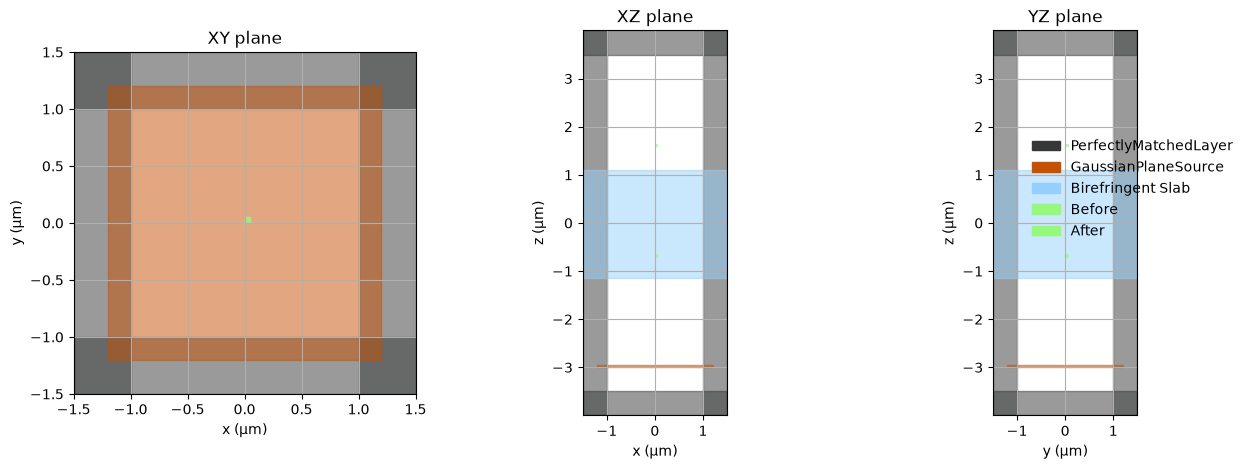

In [76]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

# Visualize the geometry & material distribution before running anything
fig = fdtdx.plot_setup(config=config, objects=objects, exclude_object_list=[video_detector])
plt.show()

### Visualizing the anisotropy in the material itself

Before even running the simulation, we can plot the two relevant diagonal components of
the permittivity tensor FDTDX built for us, and see the birefringent slab show up with a
*different* value depending on which polarization axis we look at -- this is literally
the anisotropy from Section 2, now placed inside a real geometry. `material_axis=0`
selects ($\varepsilon_{xx}$) (what `Ex` experiences), `material_axis=1` selects
($\varepsilon_{yy}$) (what `Ey`/`Ez` experience).


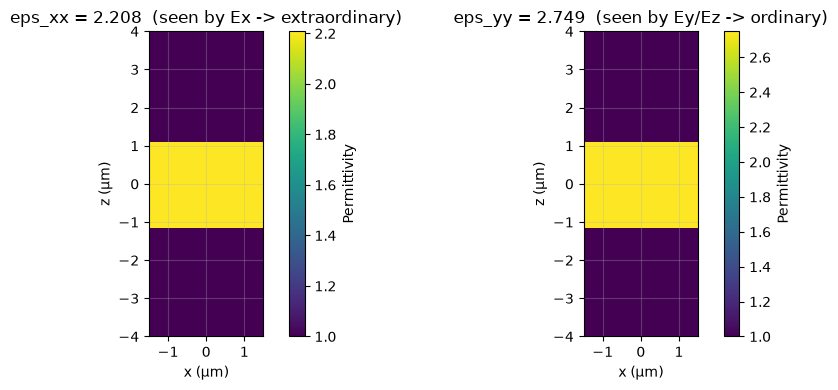

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fdtdx.plot_material_from_side(
    config=config, arrays=arrays, viewing_side="y", material_axis=0,
    type="permittivity", ax=axes[0],
)
axes[0].set_title(f"eps_xx = {eps_e:.3f}  (seen by Ex -> extraordinary)")

fdtdx.plot_material_from_side(
    config=config, arrays=arrays, viewing_side="y", material_axis=1,
    type="permittivity", ax=axes[1],
)
axes[1].set_title(f"eps_yy = {eps_o:.3f}  (seen by Ey/Ez -> ordinary)")

plt.tight_layout()
plt.show()


## 5. Running the simulation

`fdtdx.apply_params` prepares the scene, then `fdtdx.run_fdtd` performs the actual FDTD time-stepping loop. We wrap it in
`jax.jit` for speed on repeated calls.

In [82]:
def sim_fn(params, arrays, key):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(arrays=arrays, objects=new_objects, config=config, key=key)
    _, arrays = final_state
    return arrays

jitted_sim = jax.jit(sim_fn)
new_arrays = jitted_sim(params, arrays, subkey)
print("Simulation finished.")

FDTD (checkpointed):   0%|                           | 0/1574 [00:00<?, ?step/s]

Simulation finished.


### Watching the pulse cross the slab

`objects["Video"].draw_plot(...)` renders the recorded `EnergyDetector` slices into a
video file. We display it inline with `IPython.display.Video`.


In [85]:
video_paths = objects["Video"].draw_plot(new_arrays.detector_states["Video"])
print(video_paths)
Video(list(video_paths.values())[0], embed=True, width=640)


{'sliced_video': '/var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/tmpyj5nggup.mp4'}


### A snapshot of the full field distribution

`fdtdx.plot_field_slice` renders all six field components (`Ex, Ey, Ez, Hx, Hy, Hz`) for a
single 2D slice. The full 3D field arrays live under `arrays.fields.E` / `arrays.fields.H`
(a `FieldState`, not directly on the `ArrayContainer`), so we first pull out a mid-plane
(constant-`y`) slice.


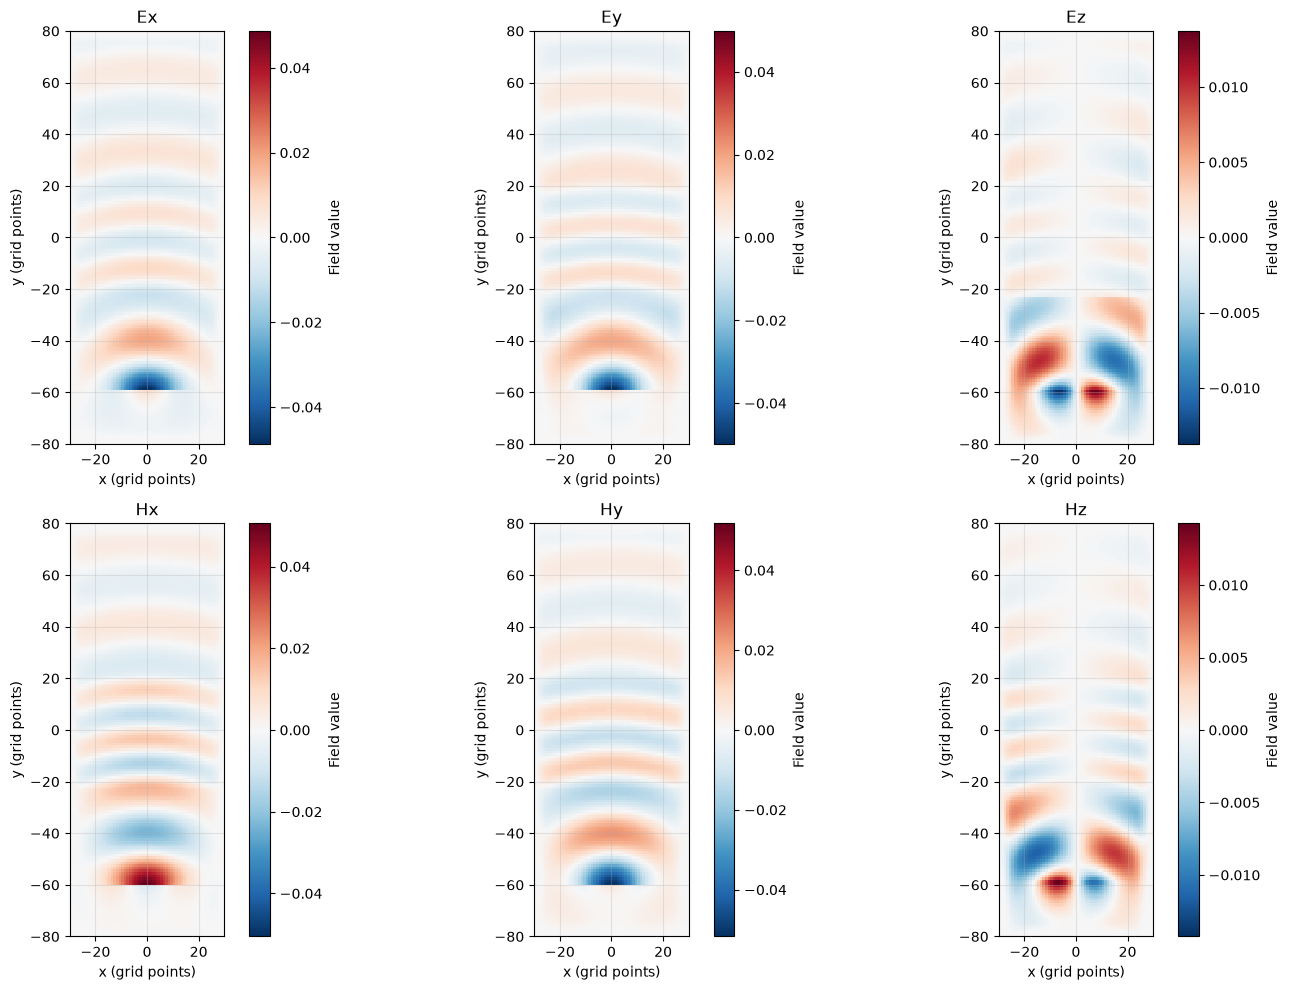

In [88]:
E_full = np.asarray(new_arrays.fields.E)
H_full = np.asarray(new_arrays.fields.H)
mid_y = E_full.shape[2] // 2
E_slice = E_full[:, :, mid_y, :]
H_slice = H_full[:, :, mid_y, :]

fig = fdtdx.plot_field_slice(E=E_slice, H=H_slice)
plt.show()


## 6. Reading out the result: phase retardation between Ex and Ey

The whole point of the birefringent slab is that `Ex` (extraordinary) and `Ey` (ordinary)
propagate through it at different phase velocities. If we picked the slab thickness for a
quarter-wave plate, a 45-degree linearly-polarized input should turn into (close to)
**circularly polarized** light after the slab, while the field measured *before* the slab
should still show the two components in phase (linear polarization).

We plot the raw `Ex(t)`, `Ey(t)` traces at both detectors, and the `Ex`-vs-`Ey` parametric
("polarization ellipse") plot, which is the clearest visual signature of birefringence.


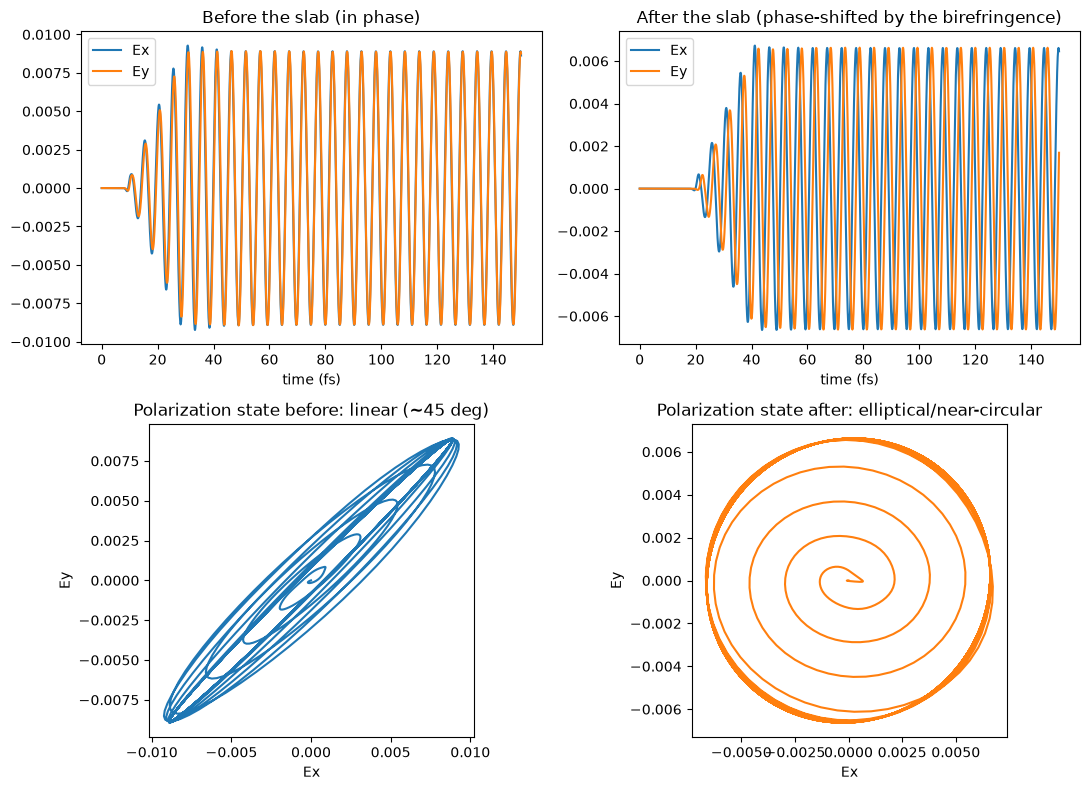

In [91]:
CANONICAL_ORDER = ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz")

def get_trace(detector_name, component):
    det = objects[detector_name]
    comp_order = [c for c in CANONICAL_ORDER if c in det.components]
    idx = comp_order.index(component)
    raw = np.asarray(new_arrays.detector_states[detector_name]["fields"])
    return raw[:, idx].reshape(-1)  # collapse the (size-1) spatial dims, keep the time axis

ex_before, ey_before = get_trace("Before", "Ex"), get_trace("Before", "Ey")
ex_after, ey_after = get_trace("After", "Ex"), get_trace("After", "Ey")

# `switch=OnOffSwitch(interval=1)` records every simulation step, so the sample
# spacing is exactly config.time_step_duration.
t_fs = np.arange(len(ex_before)) * config.time_step_duration * 1e15

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(t_fs, ex_before, label="Ex")
axes[0, 0].plot(t_fs, ey_before, label="Ey")
axes[0, 0].set_title("Before the slab (in phase)")
axes[0, 0].set_xlabel("time (fs)")
axes[0, 0].legend()

axes[0, 1].plot(t_fs, ex_after, label="Ex")
axes[0, 1].plot(t_fs, ey_after, label="Ey")
axes[0, 1].set_title("After the slab (phase-shifted by the birefringence)")
axes[0, 1].set_xlabel("time (fs)")
axes[0, 1].legend()

axes[1, 0].plot(ex_before, ey_before)
axes[1, 0].set_title("Polarization state before: linear (~45 deg)")
axes[1, 0].set_xlabel("Ex"); axes[1, 0].set_ylabel("Ey")
axes[1, 0].set_aspect("equal")

axes[1, 1].plot(ex_after, ey_after, color="tab:orange")
axes[1, 1].set_title("Polarization state after: elliptical/near-circular")
axes[1, 1].set_xlabel("Ex"); axes[1, 1].set_ylabel("Ey")
axes[1, 1].set_aspect("equal")

plt.tight_layout()
plt.show()


### Quantifying the phase retardation

Beyond eyeballing whether the ellipse "opens up", we can measure the actual phase
retardation FDTDX introduced between `Ex` and `Ey` using a Hilbert-transform-based
instantaneous phase, and compare it against the analytic value
($\Delta\phi = 2\pi (n_o - n_e) d / \lambda $) we targeted when picking the slab
thickness. We also compare the two components' frequency spectra: birefringence only
shifts *phase*, so `Ex` and `Ey` should still peak at the same optical frequency.


Measured phase retardation:      88.7 deg
Theoretical phase retardation:   90.0 deg  (target: 90 deg, quarter-wave)


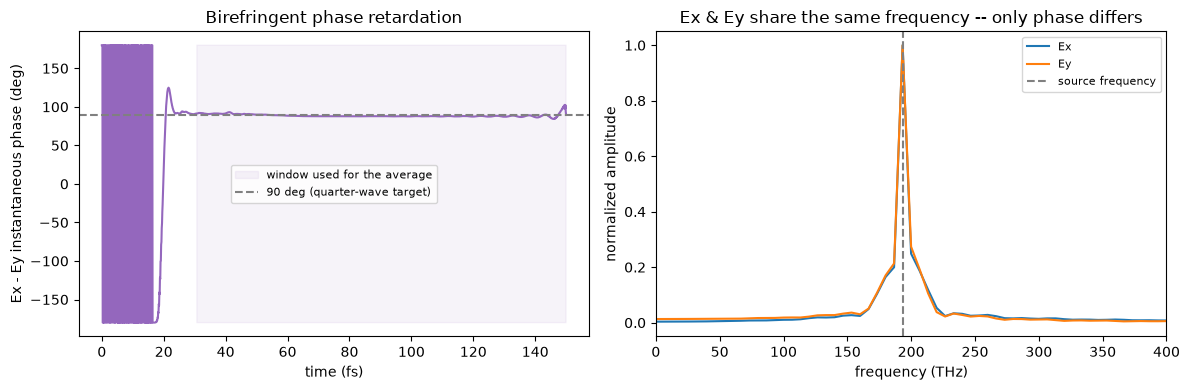

In [94]:
def instantaneous_phase(x):
    return np.unwrap(np.angle(hilbert(x)))

phase_ex = instantaneous_phase(ex_after)
phase_ey = instantaneous_phase(ey_after)
phase_diff = np.mod(phase_ex - phase_ey + np.pi, 2 * np.pi) - np.pi  # wrap to [-180, 180] deg

# Hilbert-based instantaneous phase is unreliable where the Gaussian pulse envelope
# is small (start/end of the trace), so restrict the average to the well-illuminated part.
envelope = np.abs(hilbert(ex_after)) + np.abs(hilbert(ey_after))
steady = envelope > 0.5 * envelope.max()

measured_deg = np.degrees(np.mean(phase_diff[steady]))
theory = 2 * np.pi * delta_n * slab_thickness / wavelength
theory_deg = np.degrees(np.mod(theory + np.pi, 2 * np.pi) - np.pi)

print(f"Measured phase retardation:    {measured_deg:6.1f} deg")
print(f"Theoretical phase retardation: {theory_deg:6.1f} deg  (target: 90 deg, quarter-wave)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_fs, np.degrees(phase_diff), color="tab:purple")
axes[0].fill_between(t_fs, -180, 180, where=steady, color="tab:purple", alpha=0.08,
                      label="window used for the average")
axes[0].axhline(90, color="gray", ls="--", label="90 deg (quarter-wave target)")
axes[0].set_xlabel("time (fs)")
axes[0].set_ylabel("Ex - Ey instantaneous phase (deg)")
axes[0].set_title("Birefringent phase retardation")
axes[0].legend(fontsize=8)

dt = config.time_step_duration
freqs_THz = np.fft.rfftfreq(len(ex_after), d=dt) / 1e12
spec_ex = np.abs(np.fft.rfft(ex_after))
spec_ey = np.abs(np.fft.rfft(ey_after))
axes[1].plot(freqs_THz, spec_ex / spec_ex.max(), label="Ex")
axes[1].plot(freqs_THz, spec_ey / spec_ey.max(), label="Ey")
axes[1].axvline(3e8 / wavelength / 1e12, color="gray", ls="--", label="source frequency")
axes[1].set_xlim(0, 400)
axes[1].set_xlabel("frequency (THz)")
axes[1].set_ylabel("normalized amplitude")
axes[1].set_title("Ex & Ey share the same frequency -- only phase differs")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
